> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action, write code (use AI as you need but cleanup the code)!
>
> These sections are graded and are not optional.
>

# **IS 4487 Assignment 6: Data Cleaning with Airbnb Listings**

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## **Task 1. Choose a City & Upload Your Dataset**

1.1. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)

1.2. Follow these steps to load the data.

- Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
- Choose a city you’re interested in.
- Download the file named: **`listings.csv.gz`** under that city.
- In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
- Use the file path `/content/listings.csv.gz` when loading your data.



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 🔧1.2 Load your uploaded file (path "/content/listings.csv.gz")
df = pd.read_csv('/content/listings.csv.gz')

# Display shape and first few rows
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (10369, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,28871,https://www.airbnb.com/rooms/28871,20260615212022,2026-06-16,previous scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,NaN,https://a0.muscache.com/pictures/160889/362340...,124245,...,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,NaN,2,0,2,0,4.15
1,29051,https://www.airbnb.com/rooms/29051,20260615212022,2026-06-16,previous scrape,Comfortable single / double room,This room can also be rented as a single or a ...,NaN,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.93,4.88,4.79,0363 607B EA74 0BD8 2F6F,NaN,2,0,2,0,4.88
2,44129,https://www.airbnb.com/rooms/44129,20260615212022,2026-06-24,previous scrape,Luxury design with canal view,"Welcome to my little gem<br /><br />Cozy, brig...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,187728,...,4.89,4.95,4.59,03635399E87602900F47,NaN,4,3,1,0,0.96
3,44391,https://www.airbnb.com/rooms/44391,20260615212022,2026-06-24,previous scrape,Quiet 2-bedroom Amsterdam city centre apartment,Guests greatly appreciate the unique location ...,NaN,https://a0.muscache.com/pictures/97741545/3900...,194779,...,4.90,4.68,4.50,0363 E76E F06A C1DD 172C,NaN,1,1,0,0,0.22
4,48373,https://www.airbnb.com/rooms/48373,20260615212022,2026-06-24,previous scrape,Cozy family home in Amsterdam South,Charming modern apartment in the quiet and gre...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,220434,...,5.00,4.60,5.00,0363 4A2B A6AD 0196 F684,NaN,1,1,0,0,0.14


## **Task 2. Explore Missing Values**

Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

Explore how complete your dataset is:

2.1. Count the null values of each column

2.2. Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values

Keep in mind which column(s) are missing too much data, you will delete these in the next step



Columns with missing values (showing only those with > 0 nulls):


,0
neighborhood_overview,10369
host_since,10369
host_total_listings_count,10369
neighbourhood,10369
host_verifications,10369
host_response_rate,10369
host_acceptance_rate,10369
host_thumbnail_url,10369
host_response_time,10369
host_neighbourhood,10369


/tmp/ipykernel_1745/2035774992.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_cols.head(20).values, y=missing_cols.head(20).index, palette='viridis')


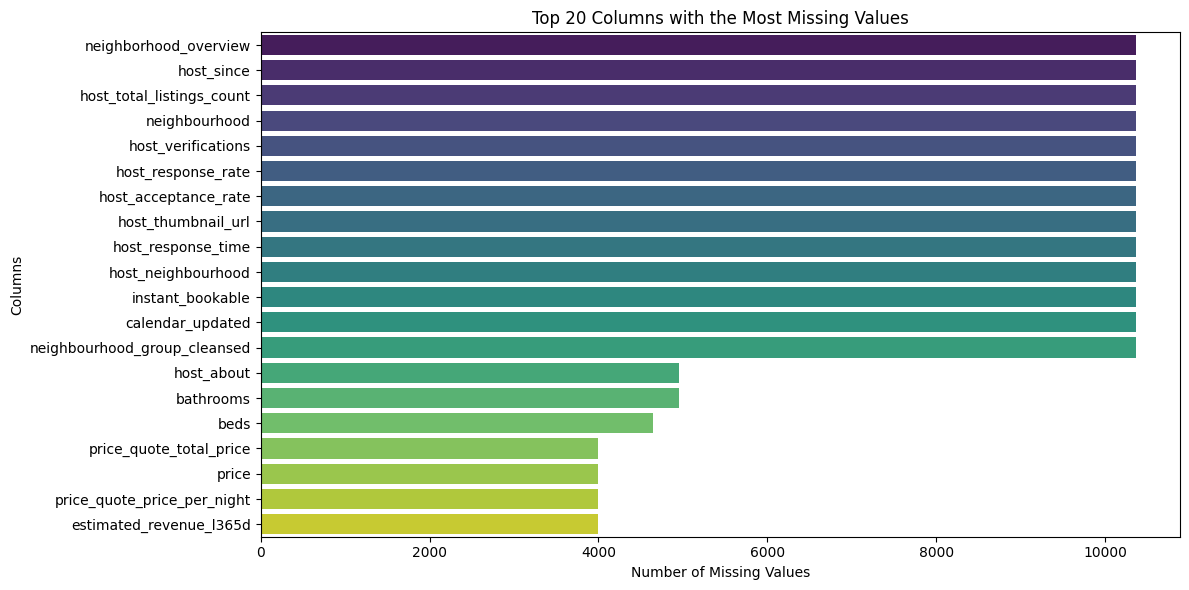

In [3]:
# 🔧 2.1. Count the null values of each column
null_counts = df.isnull().sum()
print("Columns with missing values (showing only those with > 0 nulls):")
missing_cols = null_counts[null_counts > 0].sort_values(ascending=False)
display(missing_cols)

# 🔧 2.2. Create visuals to help show what columns are missing values
# We will visualize the top columns with the most missing values
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_cols.head(20).values, y=missing_cols.head(20).index, palette='viridis')
plt.title('Top 20 Columns with the Most Missing Values')
plt.xlabel('Number of Missing Values')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

### ✍️ Please answer the following:

2.3. What are the top 3 columns with the most missing values?

2.4. Which columns are likely to create business issues?

2.5. Which columns could be safely ignored or dropped?


### ✍️ Your Response:

2.3.Top 3 columns missing are
1. neighborhood_overview	10369
2. host_since	10369
3. host_total_listings_count	10369

2.4. Possible Host acceptance (10369) rate could be an issue, price (3992) or finally Host response time (10,369)

2.5.
Safely Ignored:ID, url, and the columns that are complete empty. I had 13 that are 99% empty. I will drop those.

## **Task 3. Drop Columns That Aren’t Useful**

Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

Make a decision:

3.1. Choose 2-4 columns to drop from your dataset, and drop them.

3.2. Confirm they're gone with `.head()` or `.info()`



In [4]:
# 🔧 3.1. Choose columns to drop from your dataset, and drop them.
# Identify columns that are 100% empty (contain 10369 missing values)
empty_cols_to_drop = df.columns[df.isnull().sum() == len(df)].tolist()

print(f"Dropping {len(empty_cols_to_drop)} columns that are 100% empty:")
print(empty_cols_to_drop)

df_cleaned = df.drop(columns=empty_cols_to_drop)

# 🔧 3.2. Confirm they're gone with .head() or .info()
print("\nRemaining dataset info:")
display(df_cleaned.info())

Dropping 13 columns that are 100% empty:
['neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated', 'instant_bookable']

Remaining dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10369 entries, 0 to 10368
Data columns (total 77 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10369 non-null  int64  
 1   listing_url                                   10369 non-null  object 
 2   scrape_id                                     10369 non-null  int64  
 3   last_scraped                                  10369 non-null  object 
 4   source                                        10369 non-null  object 
 5   nam

None

### ✍️ Please answer the following:

3.3. Which columns did you drop?

3.4. Why were they not useful from a business perspective?

3.5. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
3.3. I dropped 13 columns that were 100% empty (neighborhood overview, host since, host response time, etc.

3.4. From a business perspective there is no risk in deleting these rows because they offered no value to begin with.

3.5. Deleting these columns make the data cleaner and easier to handle. I might need to do this again and see if I can delete other columns.



## **Task 4. Fill or Fix Values in Key Columns**

Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

4.1. Choose 2 columns with missing values
- Use a strategy to fill or flag those values (e.g., median, “unknown”, forward-fill, or a placeholder)

4.2. Write a command to ensure that the missing values have been addressed.


In [6]:
# 🔧 4.1. Your code for taking care of missing values for 2 columns
# Fill missing values for 'review_scores_cleanliness' and 'review_scores_communication' with their respective medians
cleanliness_median = df_cleaned['review_scores_cleanliness'].median()
communication_median = df_cleaned['review_scores_communication'].median()

df_cleaned['review_scores_cleanliness'] = df_cleaned['review_scores_cleanliness'].fillna(cleanliness_median)
df_cleaned['review_scores_communication'] = df_cleaned['review_scores_communication'].fillna(communication_median)

# 🔧 4.2. Your code to verify that missing values have been addressed in the 2 columns
print("Missing values remaining in 'review_scores_cleanliness':", df_cleaned['review_scores_cleanliness'].isnull().sum())
print("Missing values remaining in 'review_scores_communication':", df_cleaned['review_scores_communication'].isnull().sum())

Missing values remaining in 'review_scores_cleanliness': 0
Missing values remaining in 'review_scores_communication': 0


### ✍️ Please answer the following:

4.3. What two columns did you choose to address missing values in?

4.4. What method did you use for each, and why?

4.5. What risks are there in how you filled the data?

### ✍️ Your Response:
4.3. I chose `review_scores_cleanliness` and `review_scores_communication`.

4.4. I used median computation for both columns. Because review scores are highly skewed (most ratings are close to 5.0) and using the median helps eleminate outliers

4.5. The main risk is that I reduced the range/varience of the review scores by replacing missing values with median score. This could lead high assumption.

## **Task 5. Convert and Clean Data Types**

Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

5.1. Identify one column with the wrong data type
- Convert it into a usable format (e.g., from string to number)

5.2. Verify that the data type was changed



In [7]:
# 🔧 5.1. Change data type
# Inspect existing data type and some raw values of the 'price' column
print("Before cleaning:")
print(df_cleaned['price'].head())
print("Data type:", df_cleaned['price'].dtype)

# Remove symbols like '$' and ',' then convert to float
df_cleaned['price'] = df_cleaned['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_cleaned['price'] = pd.to_numeric(df_cleaned['price'], errors='coerce')

# 🔧 5.2. Verify Change data type
print("\nAfter cleaning:")
print(df_cleaned['price'].head())
print("New Data type:", df_cleaned['price'].dtype)

Before cleaning:
0     $94.00
1        NaN
2    $313.67
3        NaN
4        NaN
Name: price, dtype: object
Data type: object

After cleaning:
0     94.00
1       NaN
2    313.67
3       NaN
4       NaN
Name: price, dtype: float64
New Data type: float64


### ✍️ Please answer the following:

5.3. What column did you fix?

5.4. What cleaning steps did you apply?

5.5. How does this help prepare the data for later use?

### ✍️ Your Response:

5.3. I cleaned and fixed the price column

5.4. I removed $ signs and commons that created the prices as string instead of float.

5.5. Fixing the price column is very important because this helps summaries like mean, median, mode, max and min, calculations.

## **Task 6. Remove Duplicate Records**

Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

6.1. Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs

6.2. Remove duplicates if found - keep only one instance of each set of the duplicated rows



In [9]:
# 🔧 6.1. Check for rows that are exact duplicates or duplicate IDs
# Check for exact duplicate rows across all columns
exact_duplicates = df_cleaned.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_duplicates}")

# Check for duplicate listing IDs
id_duplicates = df_cleaned.duplicated(subset=['id']).sum()
print(f"Number of duplicate listing IDs: {id_duplicates}")

# 🔧 6.2. Remove duplicates if found
if id_duplicates > 0:
    df_cleaned = df_cleaned.drop_duplicates(subset=['id'], keep='first')
    print("Duplicate IDs removed. Keeping the first instance.")
else:
    print("No duplicate records found. Dataset remains clean.")

Number of exact duplicate rows: 0
Number of duplicate listing IDs: 0
No duplicate records found. Dataset remains clean.


### ✍️ Please answer the following:

6.3. Did you find duplicates?

6.4. How did you decide what to drop or keep?

6.5. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response:

6.3.No duplicate rows!

6.4. I did not need to drop or combine any rows

6.5. Duplicates can be risk because addresses could have multiple apartments or rooms tied to that adress. Adding these together could ruin the analysis.

## **Task 7. Export Cleaned Data**

Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed


7.1. Before wrapping up, export your cleaned Airbnb dataset to a CSV file.

```
# Steps:
# - use df.to_csv(filename, index)
# - parameter filename = "cleaned_airbnb_data.csv" is the name of the file that will be saved
# - parameter index = False prevents pandas from writing an extra column of row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

You'll need this file for **Assignment 7**, where you'll perform data transformation techniques. This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.






In [10]:
# 🔧 7.1. Export csv here
df_cleaned.to_csv('cleaned_airbnb_data.csv', index=False)
print("Dataset exported successfully to 'cleaned_airbnb_data.csv'!")

Dataset exported successfully to 'cleaned_airbnb_data.csv'!


## **Task 8. Final Reflection**

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### ✍️ Please answer the following:

8.1. What was the most surprising or challenging part of cleaning this dataset?

8.2. How did you decide which data to drop, fix, or keep?

8.3. What’s one way a business team (e.g., hosts, pricing analysts, platform ops) might benefit from the cleaned version of this data?

8.4. If you had more time, what would you explore or clean further?

8.5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

8.1. Most surprising is that I had zero duplicates in the data, also that I had 13 columns that were 99% to 100% empty. The hardest part about cleaning the data is deciding to keep or delete or input mean, median or mode into those missing rows.

8.2. I dropped all the empty columns (13) the missing data under columns like price I fixed them from string to float.

8.3. A business team will benefit from this new cleaned data in pricing analysts because I have cleaned the price rows of data that was miss categorized. This improve the numbers and analysis

8.4. I'd explore more into rows that potentially have miss categorized data like in price. I'd look more into beds, #bedrooms, quote price column, and any more that have 4,000 plus values missing.

8.5. This assignment was super helpful in learning the process on how to identify missing data, deleteing unnessecary column, and how to identify the areas you need to look further into. This cleaning makes sure we have good data to equal good results.


## Submission Instructions
✅ Checklist:
- Make sure all code cells are run and outputs are visible  
- All markdown/comment questions are answered thoughtfully  
- Save the file with your last name and first name as shown below (see detailed instructions in Lab 1 on how to do this).
- Submit the assignment as an **HTML file** on Canvas

In [11]:
!jupyter nbconvert --to html "assignment_06_ShermanEthan.ipynb"

[NbConvertApp] Converting notebook assignment_06_ShermanEthan.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 423077 bytes to assignment_06_ShermanEthan.html
